# Experiment 001 - Machine Forward True Delta Bottleneck

Step: `machine_forward_08_true_delta`

Goal: check whether the one-step true latent delta is strong enough to infer actions.

## Plot

![True delta histogram](true_delta_histogram.png)

In [1]:
from pathlib import Path
import torch
import matplotlib.pyplot as plt

student_root = Path.cwd()
while student_root.name != "Student":
    if student_root.parent == student_root:
        raise RuntimeError("Run this notebook inside the Student project tree")
    student_root = student_root.parent

probe_path = student_root / "runs/action_inference/machine_forward/machine_probe_dataset.pt"
probe = torch.load(probe_path, map_location="cpu")
dz = probe["dz"].float()

stats = {
    "shape": tuple(dz.shape),
    "mean": float(dz.mean().item()),
    "std": float(dz.std(unbiased=False).item()),
    "abs_mean": float(dz.abs().mean().item()),
    "norm_mean": float(dz.norm(dim=-1).mean().item()),
    "min": float(dz.min().item()),
    "max": float(dz.max().item()),
}
stats

{'shape': (10952, 64),
 'mean': 9.680278623136473e-08,
 'std': 0.01648215390741825,
 'abs_mean': 0.009891943074762821,
 'norm_mean': 0.10075094550848007,
 'min': -0.2134019136428833,
 'max': 0.19531911611557007}

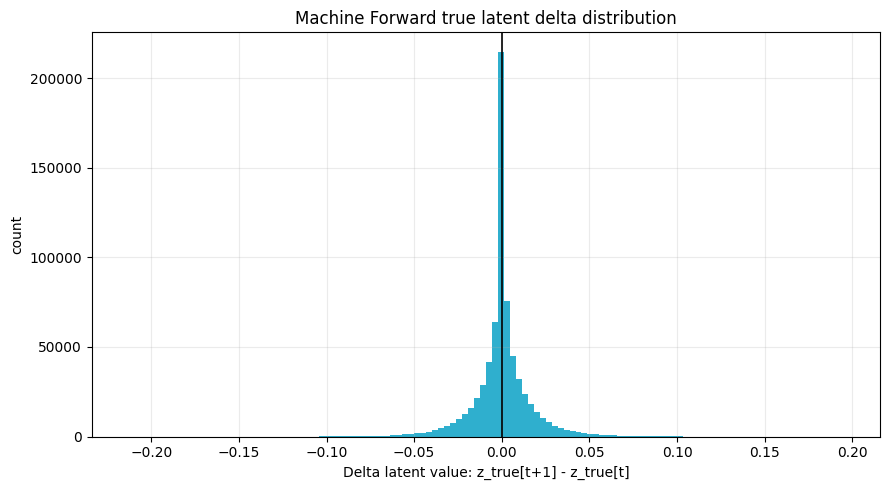

In [2]:
plt.figure(figsize=(9, 5))
plt.hist(dz.flatten().numpy(), bins=120, color="#18a7c9", alpha=0.9)
plt.axvline(0.0, color="black", linewidth=1.2)
plt.title("Machine Forward true latent delta distribution")
plt.xlabel("Delta latent value: z_true[t+1] - z_true[t]")
plt.ylabel("count")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Conclusion

First bottleneck found: one-step true latent transition is probably too small to strongly infer action.

$$\Delta z_{t+1}^{true} = z_{t+1}^{true} - z_t^{true} \approx 0$$

This explains why `MachineForward` can beat zero baseline but runtime control still tends to choose actions close to zero.

## Next Hypothesis

Run `002_machine_stride` with a larger temporal stride in Machine Forward dataset creation:

$$\Delta z_{t+s}^{true} = z_{t+s}^{true} - z_t^{true}$$

Expected effect: stronger latent delta signal, better action inference, less collapse toward zero actions in runtime control.